# Notebook 01 - Pre Processing and Data Exploration

**Authors:** Ivo Rambaldi & Tommaso Petrelli

**Course:** Ethics for Artificial Intelligence, University of Bologna, a.y. 2025-2026

---
 
## Goal 1.1 - Pre Processing and Data Exploration

This notebook implements **Goal 1** of the project: given the original data, preprocess it; i.e. manage the NaNs. perform aggragations, drop redundant columns, and splint into training and testing sets (Saved According to config.yaml).  

---

### About the target variable

The raw Aequitas dataset contains **no pre-built binary target column**. The dataset provides continuous performance scores (`score_MAT`, `score_LEN`, `score_ING`) and their ordinal level variants (1-4).
 
The binary classification target is constructed by applying a percentile threshold to the score, following the methodology of Marrero et al. (ECAI 2024), which discretises performance into quartiles to define excellence (upper tail, $\geq 75$-th percentile) and underperformance (lower tail, $\leq 25$-th percentile) detection tasks.

Our project focuses on the **excellence detection task**: a student is labelled positive (`target_high_perf = 1`) if their `score_MAT` is $\geq$ the $75$-th percentile of the training split. The threshold is computed on the training set only to prevent data leakage.

The threshold and target column name are fully configurable via `config.yaml`:

```yaml
target:
  score_column: score_MAT
  percentile:   75
  column_name:  target_high_perf
```

---

### Notebook output

This noteboook produces four CSV files written to `results/synthetic/<method>/synthetic_<method>.csv`:



In [1]:
import os
import sys
import subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


In [2]:
sys.path.append(str(Path.cwd().parent))  
print(sys.path[-1])

d:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526


In [3]:
sys.path.append(str(Path.cwd().parent))  

from src.data.loader import load_data
from src.data.preprocessor import (
    preprocess, nan_summary, bin_escs,
    ALL_SCORE_COLS, build_percentile_target
)

In [4]:

from src.utils import get_logger, load_config

cfg = load_config()
RAW_PATH  = cfg["paths"]["raw_data"]
PROC_PATH = cfg["paths"]["processed_data"]
SEED      = cfg["seed"]

SENSITIVE_COLS = cfg["dataset"]["protected_attributes"]

In [5]:
origin_data = load_data(cfg["paths"]["raw_data"], download_url=cfg["paths"].get("raw_data_url"))
origin_data.head()

d:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\src\data\loader.py:41: DtypeWarning: Columns (171,172,390) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)


,id_student,id_student_original,id_year,id_grade,id_class_group,id_school,id_student_16_19,id_school_16_19,student_questionnaire,principals_questionnaire,...,p331a,p331b,p331c,p331d,p331e,p331f,p331g,p331j,pfc,rep
0,1,33613.0,2016,3,A,2415.0,14374.0,569.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,19294.0,2016,3,A,1842.0,8001.0,273.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,19587.0,2016,3,NaN,1432.0,8142.0,82.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,29985.0,2016,3,A,2280.0,12800.0,505.0,1,1,...,2.0,2.0,3.0,2.0,3.0,3.0,NaN,NaN,NaN,NaN
4,5,6982.0,2016,3,A,2040.0,2606.0,390.0,1,1,...,4.0,NaN,4.0,4.0,4.0,3.0,NaN,NaN,NaN,NaN


In [6]:
# Target 
TARGET = cfg["target"]["score_column"]   
TARGET_COL = cfg["target"]["column_name"]    
TARGET_PCT = cfg["target"]["percentile"]     

In [7]:
# data overview 
print(f"Raw shape: {origin_data.shape}")
print(f"\nPrefix breakdown:")
for prefix, label in [("a","student"),("d","principal"),("f","family"),("p","teacher")]:
    n = sum(1 for c in origin_data.columns if c.startswith(prefix))
    print(f"  {prefix}_ ({label}): {n} cols")

# check ESCS is present in raw
print(f"\nESCS present: {'ESCS' in origin_data.columns}")
print(f"ESCS NaN:     {origin_data['ESCS'].isna().sum()} / {len(origin_data)}")

Raw shape: (83857, 561)

Prefix breakdown:
  a_ (student): 149 cols
  d_ (principal): 131 cols
  f_ (family): 81 cols
  p_ (teacher): 159 cols

ESCS present: True
ESCS NaN:     25100 / 83857


552 / 561 columns have at least one NaN



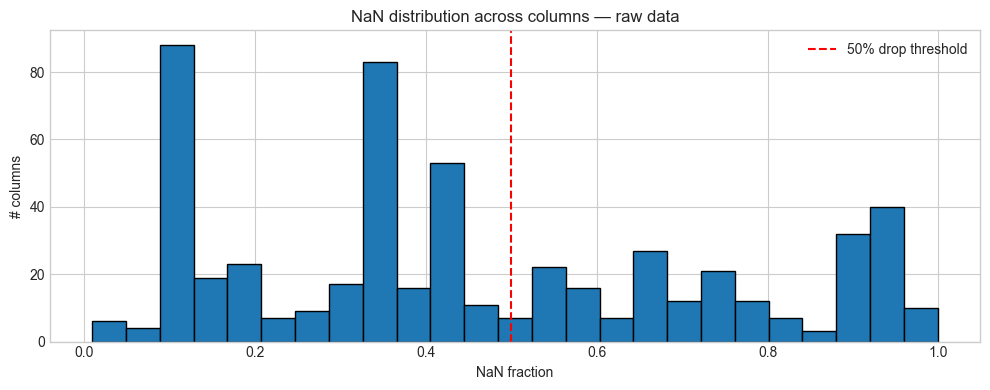

Top 15 highest-NaN columns:
       nan_count  nan_fraction
a3f        83787      0.999165
d9g1       83574      0.996625
d9g2       83527      0.996065
d302       81417      0.970903
d301       81015      0.966109
a23f       80926      0.965048
a23i       80926      0.965048
a22b       80883      0.964535
a177d      80755      0.963008
a166f      80748      0.962925
f33g       80309      0.957690
d304       80285      0.957404
f33f       80086      0.955031
f33h       79777      0.951346
f33d       79602      0.949259


In [8]:
#  NaN overview  
nan_df = nan_summary(origin_data)
print(f"{len(nan_df)} / {origin_data.shape[1]} columns have at least one NaN\n")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(nan_df["nan_fraction"], bins=25, edgecolor="black")
ax.axvline(0.5, color="red", ls="--", label="50% drop threshold")
ax.set_xlabel("NaN fraction"); ax.set_ylabel("# columns")
ax.set_title("NaN distribution across columns — raw data")
ax.legend(); plt.tight_layout(); plt.show()

print("Top 15 highest-NaN columns:")
print(nan_df.head(15).to_string())

In [9]:
# run preprocessing 
X, y_raw, sensitive = preprocess(
    origin_data,
    target_col=TARGET,
    nan_threshold=0.5,
    drop_other_scores=True,
)
print(f"\nX : {X.shape}")
print(f"y : {y_raw.shape}  |  classes: {sorted(y_raw.unique())}")
print(f"\nTarget distribution:\n{y_raw.value_counts().sort_index()}")

2026-06-29 19:54:46 | INFO     | src.data.preprocessor | Input shape: (83857, 561)
2026-06-29 19:54:47 | INFO     | src.data.preprocessor | structural drops
2026-06-29 19:54:47 | INFO     | src.data.preprocessor |   Dropping 8 identifier cols
2026-06-29 19:54:47 | INFO     | src.data.preprocessor |   Dropping 6 availability-flag cols
2026-06-29 19:54:47 | INFO     | src.data.preprocessor |   Dropping 28 redundant cols
2026-06-29 19:54:47 | INFO     | src.data.preprocessor |  row-level NaN filter
2026-06-29 19:54:47 | INFO     | src.data.preprocessor |   Dropped 3734 rows with >90% NaN
2026-06-29 19:54:47 | INFO     | src.data.preprocessor |  student aggregations
2026-06-29 19:57:30 | INFO     | src.data.preprocessor |   Dropping 126 student-agg-source cols
2026-06-29 19:57:30 | INFO     | src.data.preprocessor | family aggregations
2026-06-29 19:57:30 | INFO     | src.data.preprocessor |   Dropping 37 family-agg-source cols
2026-06-29 19:57:30 | INFO     | src.data.preprocessor |  teac

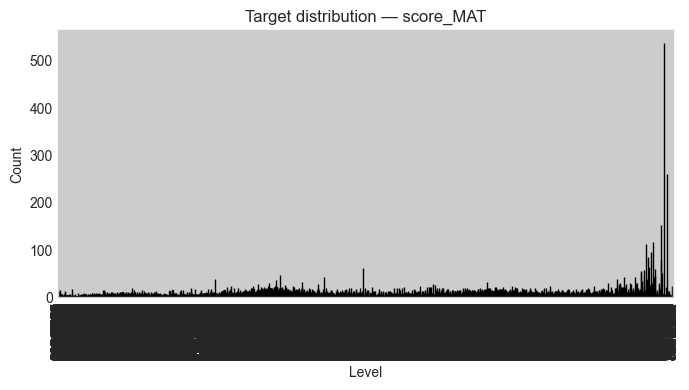

In [10]:
# target distribution 
fig, ax = plt.subplots(figsize=(7, 4))
y_raw.value_counts().sort_index().plot(kind="bar", ax=ax, edgecolor="black", color="steelblue")
ax.set_title(f"Target distribution — {TARGET}")
ax.set_xlabel("Level"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

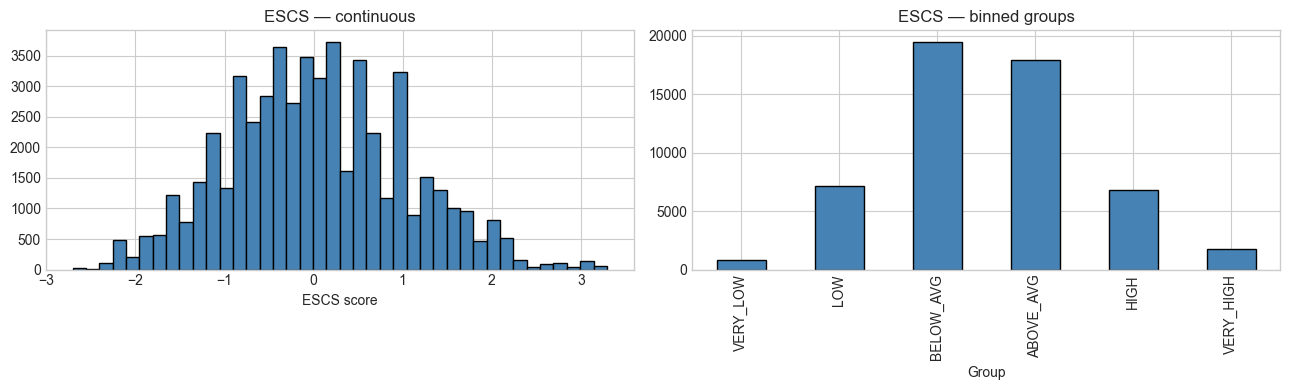

ESCS NaN: 19281 (26.4%)

ESCS group counts:
f_ESCS
VERY_LOW       787
LOW           7122
BELOW_AVG    19473
ABOVE_AVG    17891
HIGH          6842
VERY_HIGH     1756
Name: count, dtype: int64


In [11]:
# ESCS distribution 
escs_binned = bin_escs(sensitive)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(sensitive.dropna(), bins=40, edgecolor="black", color="steelblue")
axes[0].set_title("ESCS — continuous"); axes[0].set_xlabel("ESCS score")

escs_binned.value_counts().sort_index().plot(
    kind="bar", ax=axes[1], edgecolor="black", color="steelblue"
)
axes[1].set_title("ESCS — binned groups"); axes[1].set_xlabel("Group")
plt.tight_layout(); plt.show()

print(f"ESCS NaN: {sensitive.isna().sum()} ({sensitive.isna().mean():.1%})")
print(f"\nESCS group counts:\n{escs_binned.value_counts().sort_index()}")

In [12]:
#  sensitive attributes summary 
sensitive_present = [c for c in X.columns if c in SENSITIVE_COLS]

print(f"{'Column':<45} {'dtype':<12} {'unique':>6}  {'NaN%':>6}")
print("-" * 75)
for col in sensitive_present:
    print(f"{col:<45} {str(X[col].dtype):<12} {X[col].nunique(dropna=True):>6}  {X[col].isna().mean():>6.1%}")

Column                                        dtype        unique    NaN%
---------------------------------------------------------------------------
s_gender                                      object            2    0.7%
f_mother_education_level                      float64           9   27.8%
f_father_education_level                      float64           9   32.8%
f_extent_of_books_at_home                     float64           5   25.9%
f_mother_occupation                           float64           4   30.7%
f_father_occupation                           float64           4   34.8%
f_ESCS                                        float64        3043   26.4%
f_frequency_of_see_adult_read                 float64           9   35.5%


167 / 170 columns still have NaNs after preprocessing



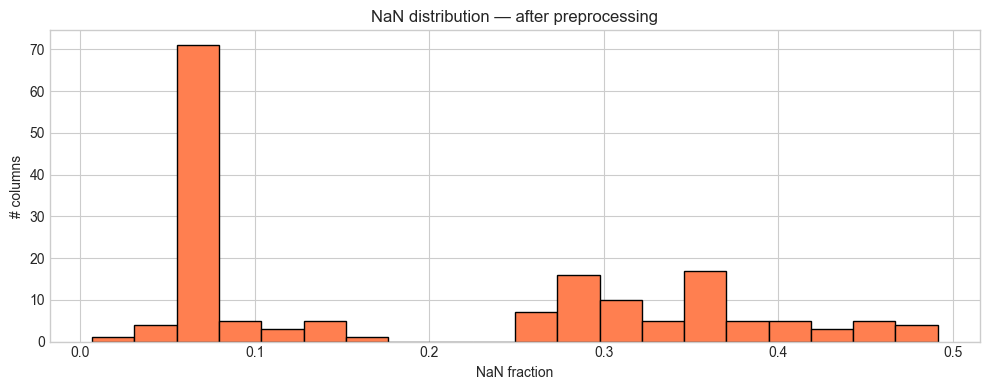

In [13]:
#  NaN overview post-preprocessing 
nan_post = nan_summary(X)
print(f"{len(nan_post)} / {X.shape[1]} columns still have NaNs after preprocessing\n")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(nan_post["nan_fraction"], bins=20, edgecolor="black", color="coral")
ax.set_xlabel("NaN fraction"); ax.set_ylabel("# columns")
ax.set_title("NaN distribution — after preprocessing")
plt.tight_layout(); plt.show()

## Imputation

The preprocessed dataset still contains missing values inherited from the survey structure —
not all respondents answered every question. We adopt a **type-aware imputation strategy**:

- **Continuous columns** → imputed with the **column median**, robust to skewed distributions
- **Ordinal integer columns** (Likert scales) → imputed with the **column mode**, preserving the discrete nature of the scale
- **Categorical columns** → assigned an explicit **`UNKNOWN` category** rather than the most frequent value, avoiding artificial inflation of any group
- **Sensitive attributes** (`f_ESCS`, income, parental education, place of birth, gender, ...) → **never imputed**; a boolean `{col}_was_nan` flag is added instead

The last point is a deliberate fairness choice: imputing protected attributes would risk
introducing spurious group membership and directly biasing the fairness metrics we aim to measure.

In [14]:
from src.data.imputation import impute, imputation_report

In [15]:
#   run imputation
X_imputed, flag_df = impute(X, sensitive_cols=SENSITIVE_COLS)

print(f"X before : {X.shape}         NaNs: {X.isna().sum().sum()}")
print(f"X after  : {X_imputed.shape} NaNs: {X_imputed.isna().sum().sum()}")
print(f"\nSensitive flag columns added: {list(flag_df.columns)}")

2026-06-29 20:01:05 | INFO     | src.data.imputation |   [FLAG]    s_gender                                      491 NaNs (0.7%)
2026-06-29 20:01:05 | INFO     | src.data.imputation |   [CONT]    a2                                            22536 NaNs → median=2005.000
2026-06-29 20:01:05 | INFO     | src.data.imputation |   [ORD]     a3a                                           27308 NaNs → mode=1
2026-06-29 20:01:05 | INFO     | src.data.imputation |   [ORD]     a3b                                           31052 NaNs → mode=1
2026-06-29 20:01:05 | INFO     | src.data.imputation |   [ORD]     living_with_father_mother                     31530 NaNs → mode=1
2026-06-29 20:01:05 | INFO     | src.data.imputation |   [ORD]     a3c                                           34732 NaNs → mode=1
2026-06-29 20:01:05 | INFO     | src.data.imputation |   [ORD]     s_birth_year                                  9599 NaNs → mode=1
2026-06-29 20:01:05 | INFO     | src.data.imputation |   [CAT]   

In [16]:
# drop the rows where s_gender is NaN; 0.7% of data, negligible
before = X_imputed.shape[0]
nan_mask = X_imputed["s_gender"].isna()
X_imputed = X_imputed[~nan_mask]
y_raw = y_raw[~nan_mask]
flag_df = flag_df[~nan_mask]
print(f"Dropped {nan_mask.sum()} rows with NaN s_gender. {before} → {X_imputed.shape[0]}")

Dropped 491 rows with NaN s_gender. 73152 → 72661


In [17]:
if "s_gender_was_nan" in flag_df.columns:
    flag_df = flag_df.drop(columns=["s_gender_was_nan"])

In [18]:
# ── Cell: imputation report ───────────────────────────────────────────────────
report = imputation_report(X, X_imputed, flag_df, sensitive_cols=SENSITIVE_COLS)

print(f"Columns that had NaNs: {len(report)}\n")
print(report.to_string())

Columns that had NaNs: 167

                                                     nan_before  nan_after  nan_fraction_before  nan_fraction_after     strategy
a61                                                       35941          0             0.491319            0.000000     ord→mode
d9e2                                                      34961          0             0.477923            0.000000  cont→median
d9d2                                                      34749          0             0.475025            0.000000  cont→median
a3c                                                       34732          0             0.474792            0.000000     ord→mode
d9e1                                                      34118          0             0.466399            0.000000  cont→median
d9d1                                                      33733          0             0.461136            0.000000  cont→median
p7an                                                      33398      

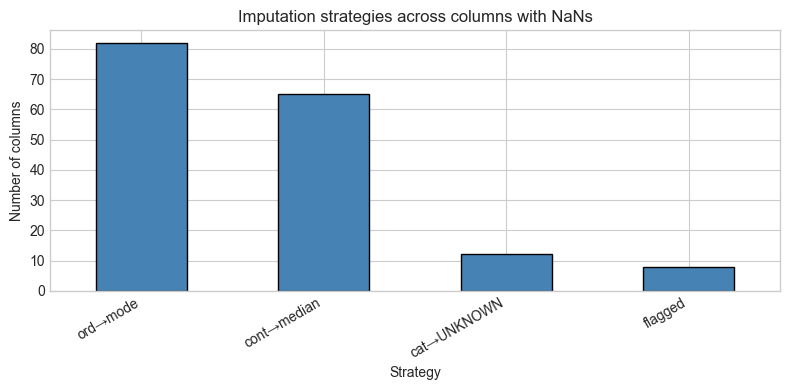

In [19]:
# imputation strategy breakdown 
strategy_counts = report["strategy"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
strategy_counts.plot(kind="bar", ax=ax, edgecolor="black", color="steelblue")
ax.set_title("Imputation strategies across columns with NaNs")
ax.set_xlabel("Strategy")
ax.set_ylabel("Number of columns")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

Sensitive attribute missingness:

Flag column                                         # missing   % missing
---------------------------------------------------------------------------
f_mother_education_level_was_nan                        20329       28.0%
f_father_education_level_was_nan                        23953       33.0%
f_extent_of_books_at_home_was_nan                       18901       26.0%
f_mother_occupation_was_nan                             22429       30.9%
f_father_occupation_was_nan                             25416       35.0%
f_ESCS_was_nan                                          19264       26.5%
f_frequency_of_see_adult_read_was_nan                   25981       35.8%


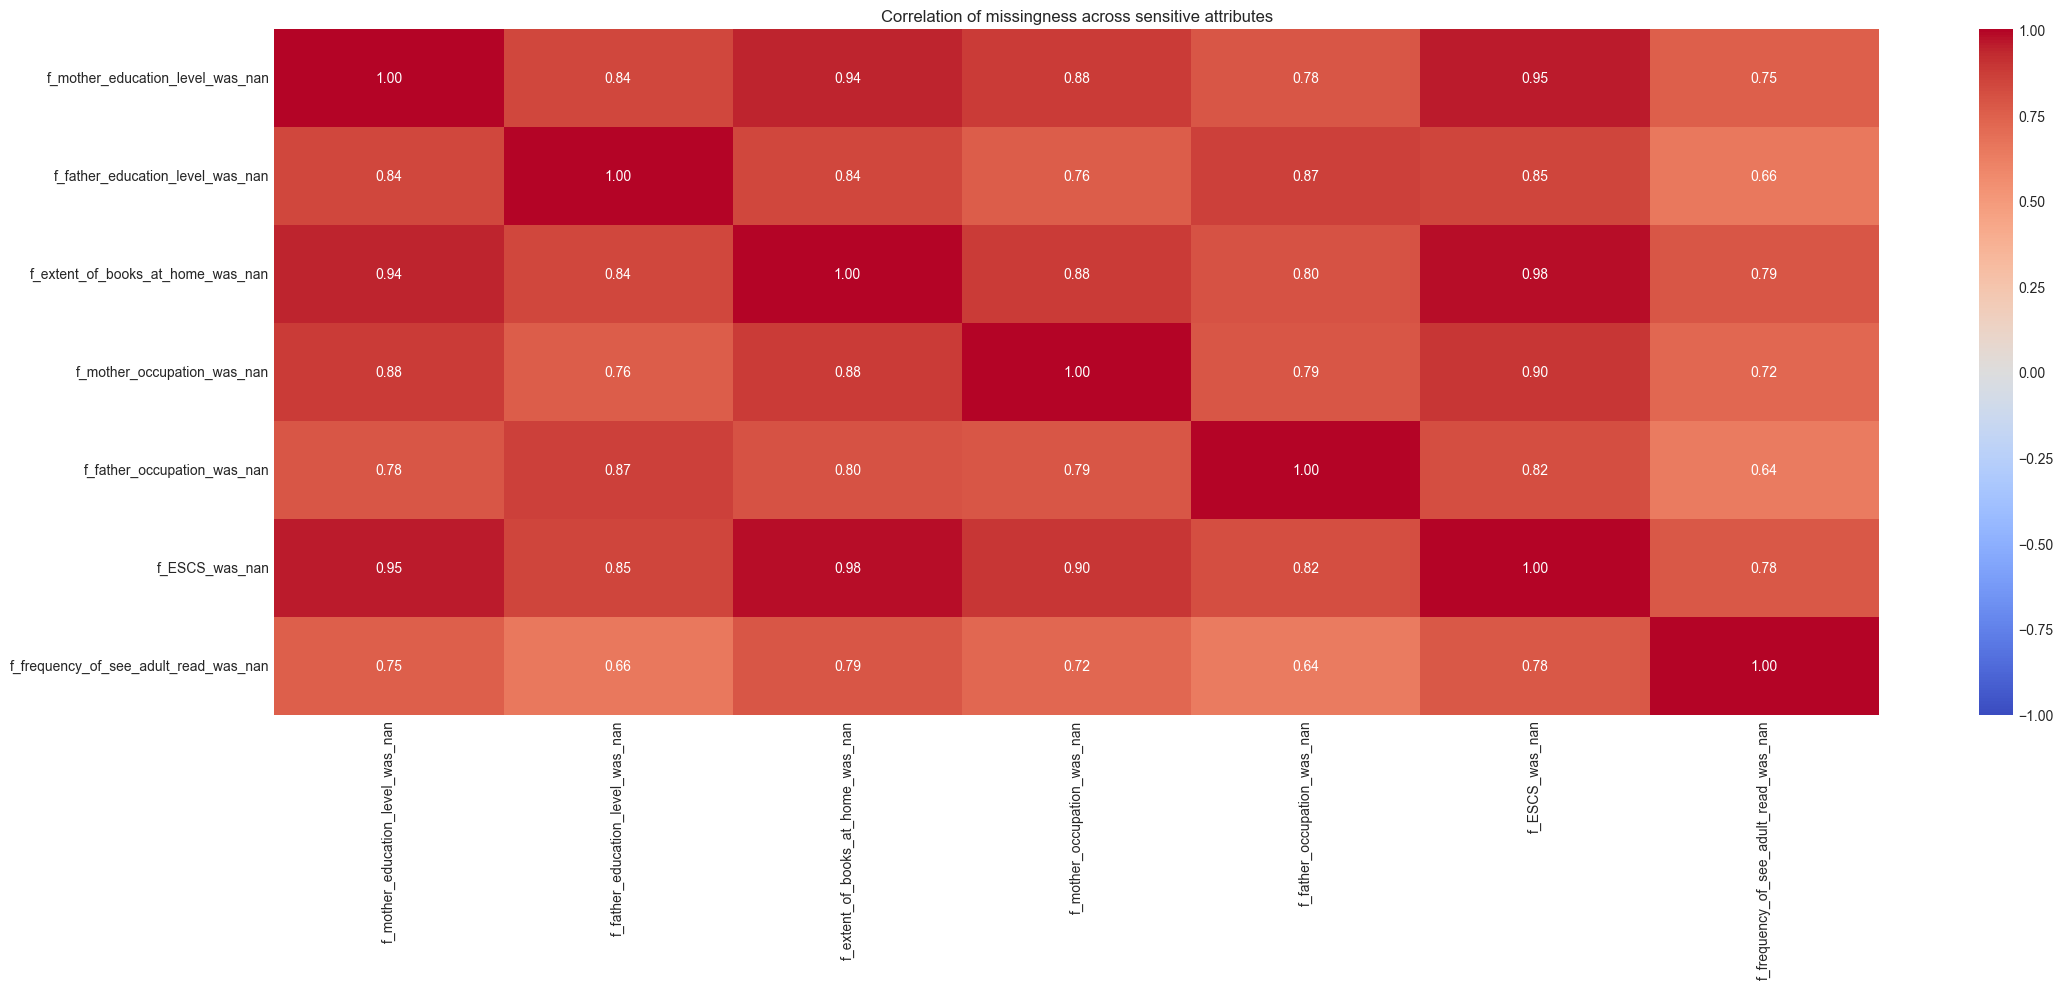

In [20]:
#  sensitive attribute NaN flags overview 
if flag_df.empty:
    print("No sensitive columns had NaNs.")
else:
    print("Sensitive attribute missingness:\n")
    print(f"{'Flag column':<50} {'# missing':>10}  {'% missing':>10}")
    print("-" * 75)
    for col in flag_df.columns:
        n = flag_df[col].sum()
        print(f"{col:<50} {n:>10}  {n/len(flag_df):>10.1%}")

    # heatmap of co-occurrence of missingness across sensitive cols
    if len(flag_df.columns) > 1:
        fig, ax = plt.subplots(figsize=(23, 10))
        sns.heatmap(
            flag_df.astype(int).corr(),
            annot=True, fmt=".2f", cmap="coolwarm",
            ax=ax, vmin=-1, vmax=1,
        )
        ax.set_title("Correlation of missingness across sensitive attributes")
        plt.tight_layout()
        plt.show()

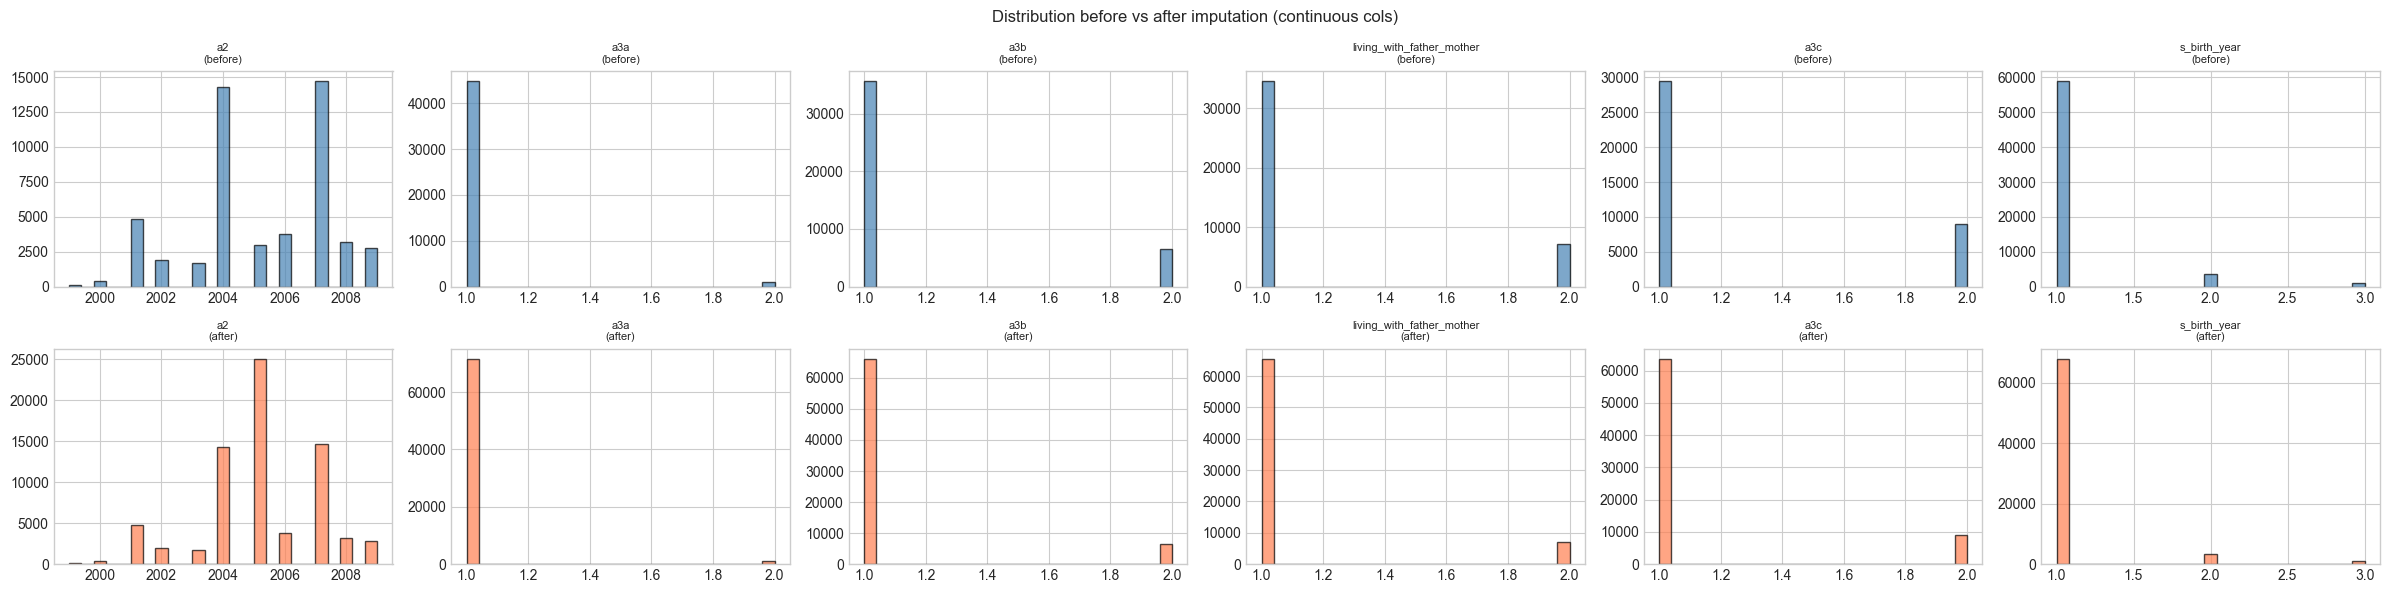

In [21]:
#  distribution check : before vs after for continuous cols 
continuous_cols = [
    c for c in X.columns
    if c not in SENSITIVE_COLS
    and X[c].isna().sum() > 0
    and X[c].dtype in [np.float64, np.int64]
    and not c.startswith("f_")   # skip sensitive-prefixed
][:6]  # cap at 6 for readability

if continuous_cols:
    fig, axes = plt.subplots(2, len(continuous_cols), figsize=(4*len(continuous_cols), 6))
    for i, col in enumerate(continuous_cols):
        axes[0, i].hist(X[col].dropna(), bins=25, edgecolor="black", color="steelblue", alpha=0.7)
        axes[0, i].set_title(f"{col}\n(before)", fontsize=8)
        axes[1, i].hist(X_imputed[col].dropna(), bins=25, edgecolor="black", color="coral", alpha=0.7)
        axes[1, i].set_title(f"{col}\n(after)", fontsize=8)
    plt.suptitle("Distribution before vs after imputation (continuous cols)")
    plt.tight_layout()
    plt.show()

## Statistical Checks

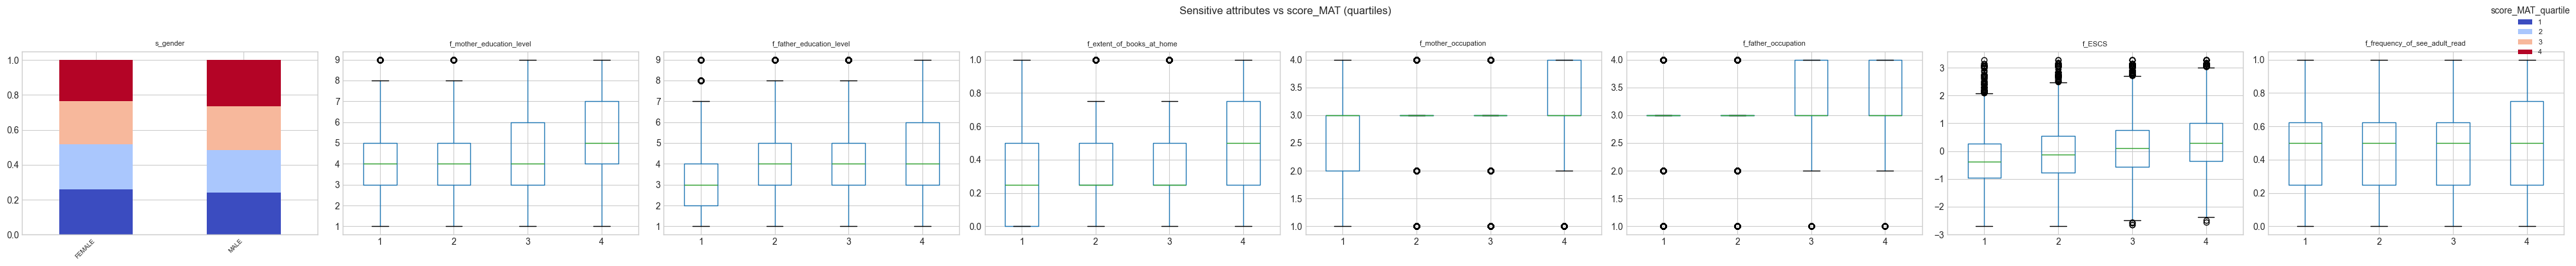

In [22]:
# sensitive attribute vs target — use binned score for plotting only
y_plot = pd.qcut(y_raw, q=4, labels=[1, 2, 3, 4])  # proxy quartile labels, no leakage risk (just for EDA)
TARGET_PLOT = "score_MAT_quartile"

plot_df = X_imputed[sensitive_present].copy()
plot_df[TARGET_PLOT] = y_plot.values

n_cols = len(sensitive_present)
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4))
if n_cols == 1:
    axes = [axes]

for ax, col in zip(axes, sensitive_present):
    if X_imputed[col].dtype == object:
        ct = pd.crosstab(plot_df[col], plot_df[TARGET_PLOT], normalize="index")
        ct.plot(kind="bar", stacked=True, ax=ax, colormap="coolwarm", legend=False)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7)
    else:
        plot_df.boxplot(column=col, by=TARGET_PLOT, ax=ax)
        plt.sca(ax); plt.title("")

    ax.set_title(col, fontsize=8)
    ax.set_xlabel("")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title=TARGET_PLOT, loc="upper right", fontsize=8)
plt.suptitle(f"Sensitive attributes vs score_MAT (quartiles)", y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Utente\AppData\Local\Temp\ipykernel_8184\2065572917.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = plot_df2.groupby(TARGET_PLOT)["f_ESCS"].mean()
C:\Users\Utente\AppData\Local\Temp\ipykernel_8184\2065572917.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stds  = plot_df2.groupby(TARGET_PLOT)["f_ESCS"].std()


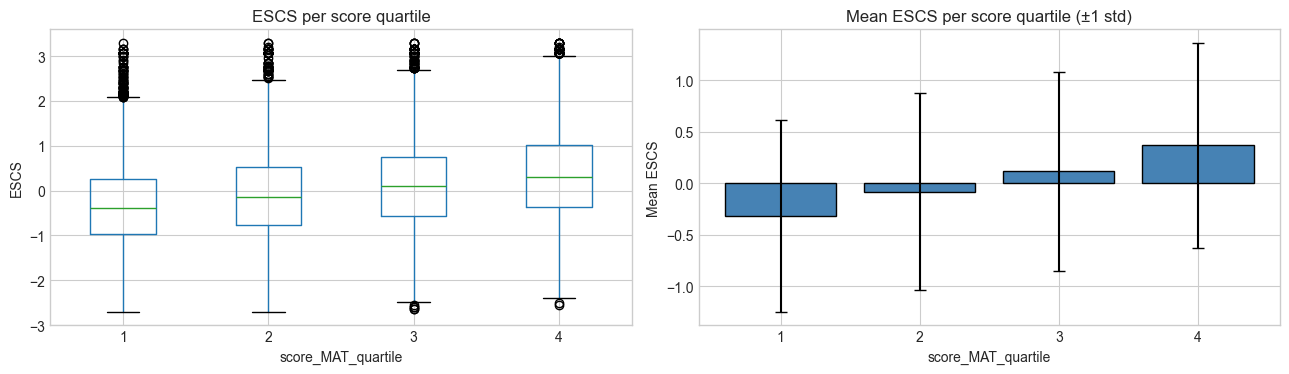

Mean ESCS per score quartile:
                     mean    std  count
score_MAT_quartile                     
1                  -0.320  0.931  12302
2                  -0.082  0.957  13074
3                   0.114  0.965  13766
4                   0.367  0.997  14255


C:\Users\Utente\AppData\Local\Temp\ipykernel_8184\2065572917.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(plot_df2.groupby(TARGET_PLOT)["f_ESCS"].agg(["mean", "std", "count"]).round(3))


In [23]:
if "f_ESCS" in X_imputed.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    plot_df2 = pd.DataFrame({"f_ESCS": X_imputed["f_ESCS"].values, TARGET_PLOT: y_plot.values})
    plot_df2.boxplot(column="f_ESCS", by=TARGET_PLOT, ax=axes[0])
    axes[0].set_title("ESCS per score quartile")
    axes[0].set_xlabel(TARGET_PLOT)
    axes[0].set_ylabel("ESCS")
    plt.sca(axes[0]); plt.title("ESCS per score quartile")

    means = plot_df2.groupby(TARGET_PLOT)["f_ESCS"].mean()
    stds  = plot_df2.groupby(TARGET_PLOT)["f_ESCS"].std()
    axes[1].bar(means.index.astype(str), means.values, yerr=stds.values,
                edgecolor="black", color="steelblue", capsize=4)
    axes[1].set_title("Mean ESCS per score quartile (±1 std)")
    axes[1].set_xlabel(TARGET_PLOT)
    axes[1].set_ylabel("Mean ESCS")

    plt.suptitle("")
    plt.tight_layout()
    plt.show()

    print("Mean ESCS per score quartile:")
    print(plot_df2.groupby(TARGET_PLOT)["f_ESCS"].agg(["mean", "std", "count"]).round(3))

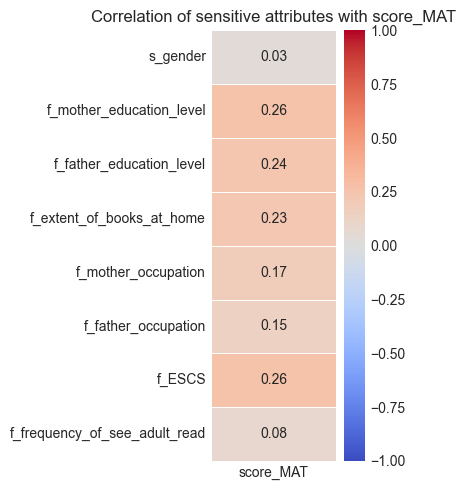

In [24]:
#  correlation heatmap , sensitive attrs vs target
from sklearn.preprocessing import OrdinalEncoder

encode_df = X_imputed[sensitive_present].copy()
encode_df[TARGET] = y_raw.values

# ordinal-encode categoricals for correlation purposes only
cat_cols = encode_df.select_dtypes(include="object").columns.tolist()
if cat_cols:
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    encode_df[cat_cols] = enc.fit_transform(encode_df[cat_cols])

encode_df = encode_df.apply(pd.to_numeric, errors="coerce")
corr = encode_df.corr()[[TARGET]].drop(TARGET)

fig, ax = plt.subplots(figsize=(4, len(sensitive_present) * 0.5 + 1))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, ax=ax, linewidths=0.5,
)
ax.set_title(f"Correlation of sensitive attributes with {TARGET}")
plt.tight_layout()
plt.show()

## Save

2026-06-29 20:01:09 | INFO     | src.data.preprocessor | Binary target 'target_high_perf': threshold=569.009 (p75 of train split only), train positive rate=25.0%, test positive rate=24.4%
Threshold: 569.009  |  Train positive rate: 25.0%

Train : (58128, 170)  |  Test : (14533, 170)

Class balance (train):
target_high_perf
0    0.75
1    0.25
Name: proportion, dtype: float64

Class balance (test):
target_high_perf
0    0.756
1    0.244
Name: proportion, dtype: float64


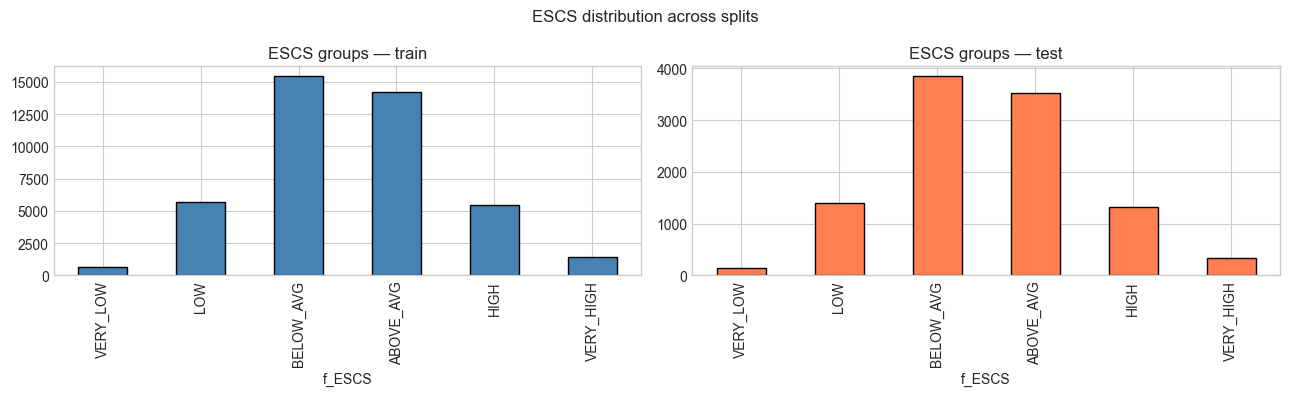

In [25]:
from sklearn.model_selection import train_test_split

TRAIN_PATH = cfg["paths"]["train_data"]
TEST_PATH  = cfg["paths"]["test_data"]

X_train, X_test, y_raw_train, y_raw_test = train_test_split(
    X_imputed, y_raw, test_size=0.2, random_state=SEED
)

y_train, y_test, threshold = build_percentile_target(
    y_raw_train, y_raw_test, percentile=TARGET_PCT, column_name=TARGET_COL
)

print(f"Threshold: {threshold:.3f}  |  Train positive rate: {y_train.mean():.1%}")
print(f"\nTrain : {X_train.shape}  |  Test : {X_test.shape}")
print(f"\nClass balance (train):\n{y_train.value_counts(normalize=True).sort_index().round(3)}")
print(f"\nClass balance (test):\n{y_test.value_counts(normalize=True).sort_index().round(3)}")

if "f_ESCS" in X_train.columns:
    escs_train = bin_escs(X_train["f_ESCS"])
    escs_test  = bin_escs(X_test["f_ESCS"])
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    escs_train.value_counts().sort_index().plot(kind="bar", ax=axes[0], edgecolor="black", color="steelblue")
    axes[0].set_title("ESCS groups — train")
    escs_test.value_counts().sort_index().plot(kind="bar", ax=axes[1], edgecolor="black", color="coral")
    axes[1].set_title("ESCS groups — test")
    plt.suptitle("ESCS distribution across splits")
    plt.tight_layout()
    plt.show()

## Feature selection

`preprocess()` still leaves a large number of raw, never-aggregated
questionnaire columns in `X` (mostly principal/teacher survey items with no
rename or aggregation rule) — these add dimensionality and noise to both the
classifiers and the synthetic-data generators (CTGAN/TVAE in particular)
without adding much signal.

`select_features()` (`src/data/feature_selection.py`) scores every
**non-sensitive** candidate column's relevance to `target_high_perf` (via
mutual information, by default) and keeps only the top `k`. Every configured
protected attribute (`SENSITIVE_COLS`) is always kept regardless of its
score, asthe  fairness auditing needs them whether or not they're
individually predictive. The kept non-sensitive columns are exactly the
ones found informative for the target.

The per-column scores are saved to `results/feature_selection_scores.csv` so the selection is always inspectable.

In [26]:
from src.data.feature_selection import select_features

selected_cols, fs_scores = select_features(X_train, y_train, SENSITIVE_COLS, cfg)

print(f"Feature selection: kept {len(selected_cols)} / {X_train.shape[1]} columns "
      f"(method={cfg['feature_selection'].get('method')}, "
      f"enabled={cfg['feature_selection'].get('enabled')})")

if not fs_scores.empty:
    fs_scores_path = cfg["paths"]["results_dir"] / "feature_selection_scores.csv"
    fs_scores_path.parent.mkdir(parents=True, exist_ok=True)
    fs_scores.to_csv(fs_scores_path, index=False)
    print(f"Per-column scores saved -> {fs_scores_path}")
    print("\nTop 15 scored columns:")
    print(fs_scores.head(15).to_string(index=False))

X_imputed = X_imputed[selected_cols]
X_train   = X_train[selected_cols]
X_test    = X_test[selected_cols]

2026-06-29 20:01:35 | INFO     | src.data.feature_selection | Feature selection (mutual_info): kept 25/162 non-sensitive candidates + 12 protected attrs -> 33 total columns.
Feature selection: kept 33 / 170 columns (method=mutual_info, enabled=True)
Per-column scores saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\feature_selection_scores.csv

Top 15 scored columns:
                        column    score  selected
                          d9a1 0.024249      True
                          d9c1 0.023499      True
                          d9b1 0.018587      True
                public_private 0.016481      True
                  s_birth_year 0.014525      True
                         d16cn 0.013609      True
                          d9a2 0.012796      True
f_frequency_of_support_at_home 0.012419      True
                          d9e1 0.012414      True
   t_extent_of_cla

In [27]:
for path in [TRAIN_PATH, TEST_PATH, PROC_PATH]:
    os.makedirs(os.path.dirname(path), exist_ok=True)

# full processed dataset
final_df = X_imputed.copy()
if not flag_df.empty:
    final_df = pd.concat([final_df, flag_df], axis=1)
final_df[TARGET_COL] = (y_raw >= threshold).astype(int)
final_df.to_csv(PROC_PATH, index=False)

# train split
train_df = X_train.copy()
if not flag_df.empty:
    train_df = pd.concat([train_df, flag_df.loc[X_train.index]], axis=1)
train_df[TARGET_COL] = y_train
train_df.to_csv(TRAIN_PATH, index=False)

# test split
test_df = X_test.copy()
if not flag_df.empty:
    test_df = pd.concat([test_df, flag_df.loc[X_test.index]], axis=1)
test_df[TARGET_COL] = y_test
test_df.to_csv(TEST_PATH, index=False)

print(f"Saved processed → {PROC_PATH}  |  shape: {final_df.shape}")
print(f"Saved train     → {TRAIN_PATH}  |  shape: {train_df.shape}")
print(f"Saved test      → {TEST_PATH}   |  shape: {test_df.shape}")

Saved processed → D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\Data\processed.csv  |  shape: (72661, 41)
Saved train     → D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\Data\train.csv  |  shape: (58128, 41)
Saved test      → D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\Data\test.csv   |  shape: (14533, 41)
